# Tilt angle calibration following Bramati et al. (2024)

Horizontal flights for calibration @scirocco:/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords:
* DJIFlightRecord_2025-11-03_[10-45-24].txt
* DJIFlightRecord_2025-11-03_[11-08-09].txt
* DJIFlightRecord_2025-11-03_[10-56-31].txt

## Trisonica for ref wind speed

In [20]:
## Trisonica for ref wind speed
import pandas as pd
import numpy as np
tris_df = pd.read_csv('/indian/UAS_project_data/2025_11_03_Arluno/trisonica/20251103_092855_1.csv',sep=';',header=8)
vars_to_keep = np.array(['Time (UTC)',' C.wspd',' C.wdir'])
tris_df = tris_df[vars_to_keep]
tris_df['Time (UTC)'] = [ np.datetime64('2025-11-03T'+time,'s') for time in tris_df['Time (UTC)']]
tris_df['Time (UTC) dt'] = [ pd.to_datetime(time,utc=True) for time in tris_df['Time (UTC)']]
tris_df.sort_values(by='Time (UTC)',inplace=True)
tris_df = tris_df.reset_index().rename_axis(None, axis=1)

tris_df

,index,Time (UTC),C.wspd,C.wdir,Time (UTC) dt
0,0,2025-11-03 09:28:55,0.84,261,2025-11-03 09:28:55+00:00
1,1,2025-11-03 09:28:55,0.98,256,2025-11-03 09:28:55+00:00
2,2,2025-11-03 09:28:55,1.17,256,2025-11-03 09:28:55+00:00
3,3,2025-11-03 09:28:55,1.16,262,2025-11-03 09:28:55+00:00
4,4,2025-11-03 09:28:56,0.93,272,2025-11-03 09:28:56+00:00
...,...,...,...,...,...
15549,15551,2025-11-03 10:20:45,0.48,57,2025-11-03 10:20:45+00:00
15550,15552,2025-11-03 10:20:45,0.31,70,2025-11-03 10:20:45+00:00
15551,15549,2025-11-03 10:20:45,0.17,89,2025-11-03 10:20:45+00:00
15552,15550,2025-11-03 10:20:45,0.19,67,2025-11-03 10:20:45+00:00


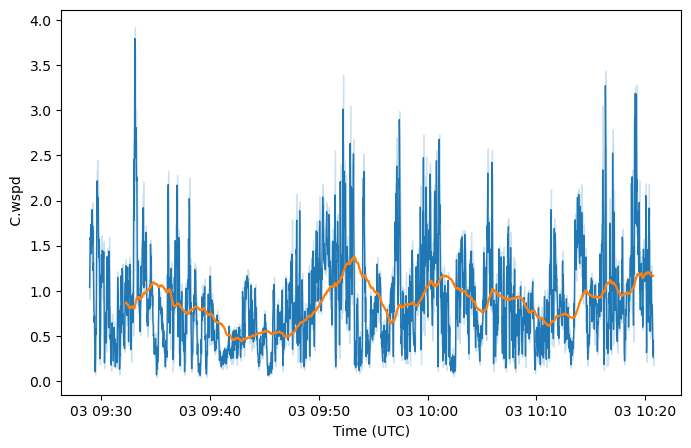

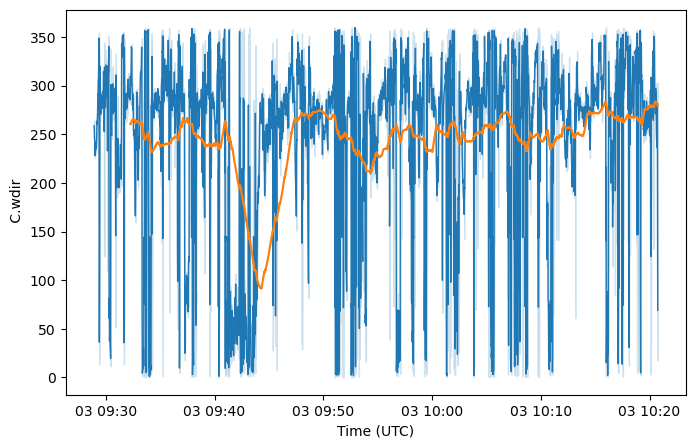

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(8,5))
sns.lineplot(
    data=tris_df,
    x='Time (UTC)',
    y=' C.wspd',
    linestyle='solid',
    linewidth=1,
    ax=ax,
)

ax.plot(tris_df['Time (UTC)'],tris_df[' C.wspd'].rolling(window=1000).mean())

fig,ax=plt.subplots(figsize=(8,5))
sns.lineplot(
    data=tris_df,
    x='Time (UTC)',
    y=' C.wdir',
    linestyle='solid',
    linewidth=1,
    ax=ax,
)
ax.plot(tris_df['Time (UTC)'],tris_df[' C.wdir'].rolling(window=1000).mean())



## UAS data

Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
Dropping 0 rows with datetime errors.
3 3267
6 1484
8 988
10 645
12 419


/tmp/ipykernel_126127/485520168.py:71: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'forward' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fr_df.loc[


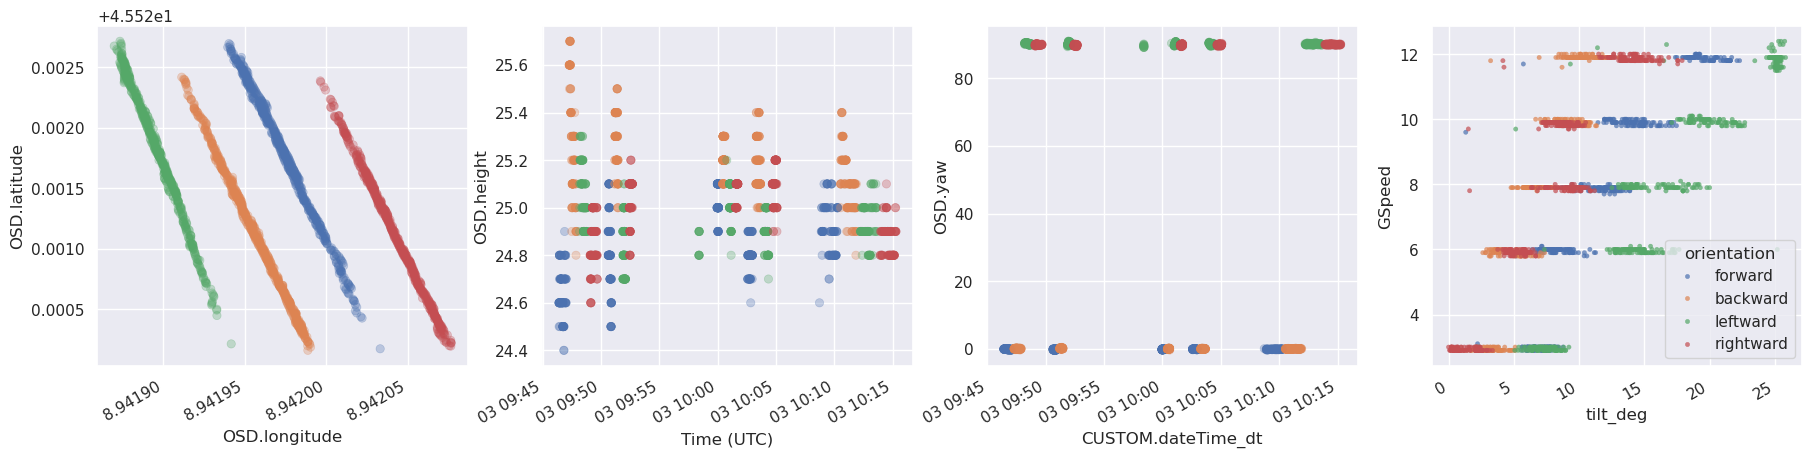

,OSD.latitude,OSD.longitude,OSD.height,OSD.altitude,OSD.xSpeed,OSD.ySpeed,OSD.zSpeed,OSD.pitch,OSD.roll,OSD.yaw,...,OSD.roll_rad,OSD.pitch_rad,tilt_rad,tilt_deg,GSpeed,C.wspd,C.wdir,GSpeed_mean,GSpeed_rel_a,orientation
0,45.520673,8.942015,24.6,109.87393,6.0,-0.2,0.0,-9.0,0.9,0.0,...,0.015708,-0.157080,0.157889,9.046367,6.003332,0.74,9,5.865098,0.023569,forward
1,45.520684,8.942015,24.6,109.87393,6.0,-0.2,0.0,-8.8,1.3,0.0,...,0.022689,-0.153589,0.155272,8.896457,6.003332,0.86,23,5.922133,0.013711,forward
2,45.520689,8.942015,24.6,109.87393,6.0,-0.2,0.0,-9.2,1.5,0.0,...,0.026180,-0.160570,0.162710,9.322587,6.003332,0.86,23,5.946152,0.009616,forward
3,45.520700,8.942014,24.6,109.87393,6.0,-0.2,-0.1,-8.4,1.7,0.0,...,0.029671,-0.146608,0.149583,8.570500,6.003332,0.86,23,5.985120,0.003043,forward
4,45.520706,8.942014,24.5,109.77393,6.0,-0.2,-0.1,-8.4,1.8,-0.1,...,0.031416,-0.146608,0.149937,8.590769,6.003332,0.69,11,6.000109,0.000537,forward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,45.520245,8.942076,25.0,110.10566,-2.9,0.0,0.0,-1.2,1.1,89.9,...,0.019199,-0.020944,0.028411,1.627828,2.900000,0.65,17,2.897939,0.000711,rightward
1996,45.520229,8.942076,24.9,110.00566,-2.9,0.0,0.0,-1.5,1.7,89.8,...,0.029671,-0.026180,0.039567,2.267013,2.900000,0.98,11,2.897904,0.000723,rightward
1997,45.520221,8.942077,24.9,110.00566,-2.9,0.0,0.0,-1.5,1.4,90.1,...,0.024435,-0.026180,0.035809,2.051720,2.900000,0.95,9,2.898869,0.000390,rightward
1998,45.520224,8.942076,24.9,110.00566,-2.9,0.0,0.0,-1.7,1.6,89.9,...,0.027925,-0.029671,0.040742,2.334365,2.900000,0.95,9,2.898886,0.000384,rightward


In [ ]:
import os
import sys
sys.path.append('./..')
from src.preprocess import PreprocessFlightRecord,PlotFlightRecord
from src.tilt_angle import AddTiltAngle,AddGroundSpeed
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2


flights_dict = {
    'DJIFlightRecord_2025-11-03_[10-45-24].csv' : {
        'itime_int' : [500,4450], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[10-56-31].csv' : {
        'itime_int' : [200,5200], # Interval of indices to consider 
    },
    'DJIFlightRecord_2025-11-03_[11-08-09].csv' : {
        'itime_int' : [200,4700], # Interval of indices to consider 
    },
    }


files = np.array(sorted(glob.glob(f"/indian/UAS_project_data/2025_11_03_Arluno/MAVIC/FlightRecords/*")))
files = files[[ True if os.path.basename(file) in flights_dict.keys() else False for file in files ]]

fr_df_ar = []
for file in files:
    flight_dict = flights_dict[os.path.basename(file)]
    fr_df = PreprocessFlightRecord(file,itime_int=flight_dict['itime_int'])
    fr_df = AddTiltAngle(fr_df)
    fr_df = AddGroundSpeed(fr_df)
    fr_df_ar.append(fr_df)


fr_df = pd.concat(fr_df_ar)
fr_df['CUSTOM.dateTime_dt'] = [ pd.to_datetime(time,utc=True) for time in fr_df['CUSTOM.dateTime_dt']]
fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)

# Interpolate trisonica data
fr_df = pd.merge_asof(fr_df, tris_df, left_on='CUSTOM.dateTime_dt', right_on='Time (UTC) dt', direction='nearest', tolerance=pd.Timedelta('1s')).drop(axis='columns',columns=['index', 'Time (UTC)','Time (UTC) dt'])

# Keep legs only
fr_df = fr_df.loc[((fr_df['OSD.yaw'] > 89) & (fr_df['OSD.yaw'] < 91)) | ((fr_df['OSD.yaw'] > -1) & (fr_df['OSD.yaw'] < 1)) ]

# Remove accelerations and decelerations
window=100
fr_df['GSpeed_mean'] = fr_df['GSpeed'].rolling(window=window).mean()
fr_df['GSpeed_rel_a'] = np.abs(fr_df['GSpeed_mean']-fr_df['GSpeed'])/fr_df['GSpeed_mean'] 
# Empirical threshold for GSpeed relative anomaly
GS_rel_a_threshold = 0.03
fr_df = fr_df.loc[(fr_df['GSpeed_rel_a']< GS_rel_a_threshold)].reset_index(drop=True)
fr_df.reset_index(inplace=True,drop=True)

# Save info on orientation
orientations_dict = {
    'forward' : {'OSD.yaw' : [-1,1],'OSD.xSpeed' : [0,np.inf]},
    'backward' : {'OSD.yaw' : [-1,1],'OSD.xSpeed' : [-np.inf,0]},
    'leftward' : {'OSD.yaw' : [89,91],'OSD.xSpeed' : [0,np.inf]},
    'rightward' : {'OSD.yaw' : [89,91],'OSD.xSpeed' : [-np.inf,0]},
}

fr_df['orientation'] = np.zeros_like(fr_df['GSpeed'])
for orientation in orientations_dict.keys():
    xSpeed_bnd = orientations_dict[orientation]['OSD.xSpeed']
    yaw_bnd = orientations_dict[orientation]['OSD.yaw']
    fr_df.loc[
        (fr_df['OSD.xSpeed']>xSpeed_bnd[0]) & 
        (fr_df['OSD.xSpeed']<xSpeed_bnd[1]) & 
        (fr_df['OSD.yaw']>yaw_bnd[0]) & 
        (fr_df['OSD.yaw']<yaw_bnd[1]),'orientation'] = orientation

# Sample a fixed number of points per GSpeed
GSpeed_values = [3,6,8,10,12]#,15]
gs_df_ar = []
for GSpeed_value in GSpeed_values:
    gs_df = fr_df.loc[(fr_df['GSpeed'] > GSpeed_value-0.5) & (fr_df['GSpeed'] < GSpeed_value+0.5)]
    print(GSpeed_value,len(gs_df))
    gs_df_ar.append(gs_df.sample(n=400))    

fr_df = pd.concat(gs_df_ar).reset_index(drop=True)
fr_df.sort_values(by='CUSTOM.dateTime_dt',inplace=True)
fr_df.reset_index(inplace=True,drop=True)

# Compute TAS (true air speed wrt UAS)
# trisonica is pointing E (90° wrt N), [0,360].
# Look at maps for position and xSpeed,ySpeed,yaw in each leg to understand the orientation of MAVIC data.
# REVIEW: I'm assuming OSD.yaw is wrt N, positive towards the E, neg towards the W, [-180,180].
fr_df[' C.wdir'] = (fr_df[' C.wdir']+90)%360 # wrt N, positive E
PlotFlightRecord(fr_df)

fr_df

## Direct method

c3 : 72.15103014700327,c2 : -125.41539746035005,c1 : 67.17390995205146,c0 : 0.3289857282060863


/tmp/ipykernel_121650/912769592.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_df['ws_dm'] = c3 * fr_df['tilt_rad']**3 + c2* fr_df['tilt_rad']**2 + c1 * fr_df['tilt_rad'] + c0


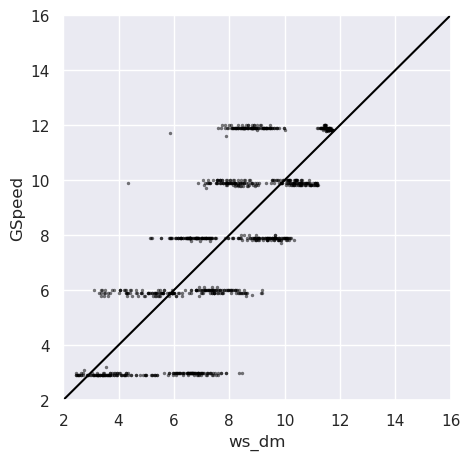

In [17]:
import numpy as np
fr_df = fr_df.loc[(fr_df['orientation'] == 'forward') | (fr_df['orientation'] == 'backward')]
#fr_df = fr_df.loc[(fr_df['orientation'] == 'leftward') | (fr_df['orientation'] == 'rightward')]

c3,c2,c1,c0 = np.polyfit(x=fr_df['tilt_rad'],y=fr_df['GSpeed'],deg=3)

# Compute wind speed from Direct Model (polyfit)
fr_df['ws_dm'] = c3 * fr_df['tilt_rad']**3 + c2* fr_df['tilt_rad']**2 + c1 * fr_df['tilt_rad'] + c0

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=fr_df,
    x='ws_dm',
    y='GSpeed',
    color='black',
    edgecolor=None,
    s=5,
    alpha=0.5,    
)

plt.plot(np.arange(0,17,1),color='black')
plt.xlim((2,16))
plt.ylim((2,16))
print(f"c3 : {c3},c2 : {c2},c1 : {c1},c0 : {c0}")

## $C_A$ method (single direction)

See /home/lorenzo/Documents/HErZ_SummerSchool/uas-analysis/uas-data/scripts/wind-calib.py

/tmp/ipykernel_121650/2438870211.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_df['CA'] = np.nan
/tmp/ipykernel_121650/2438870211.py:66: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fr_df['GSpeed_class'] = pd.cut(fr_df['GSpeed'], bins=bins, labels=labels)
/tmp/ipykernel_121650/2438870211.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

Fitted parameters: c0 = 0.14801018474128133, c1 = 223.99045766510187, c2 = 0.8098831693122878
c2 : 0.8098831693122878,c1 : 223.99045766510187,c0 : 0.14801018474128133


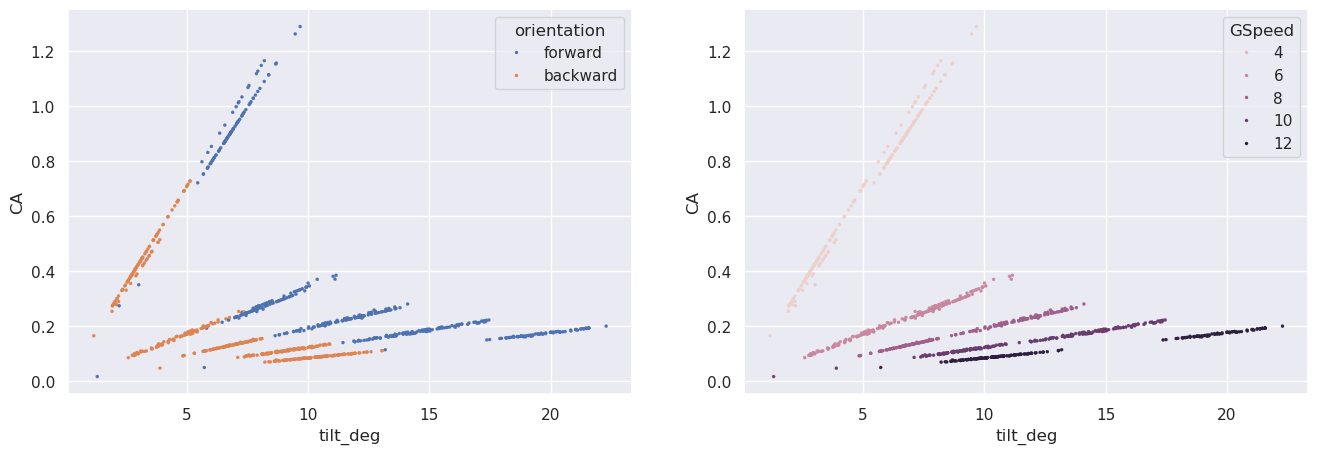

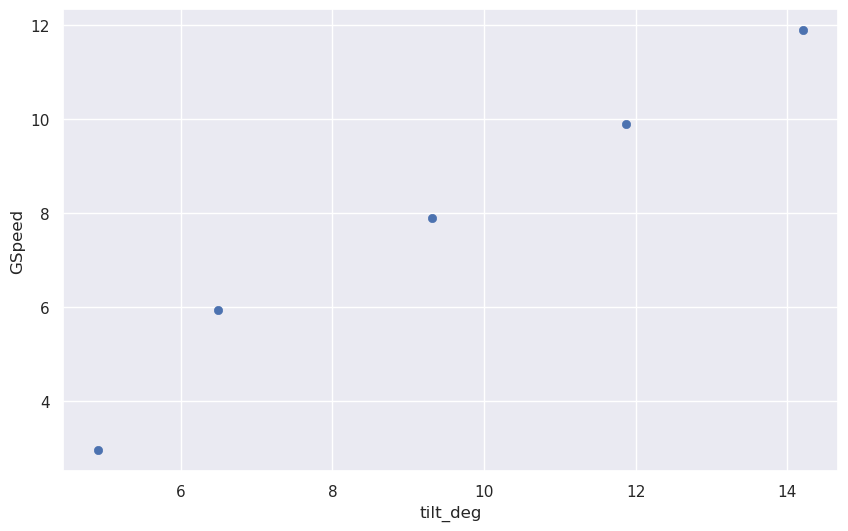

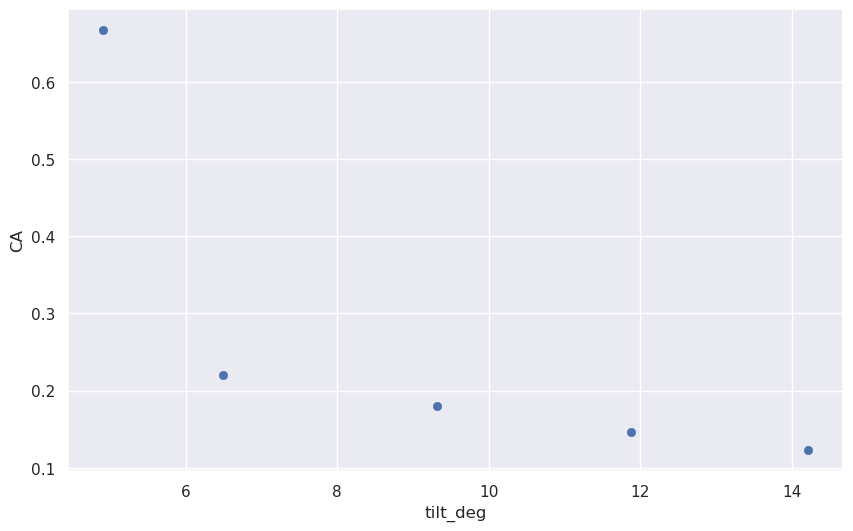

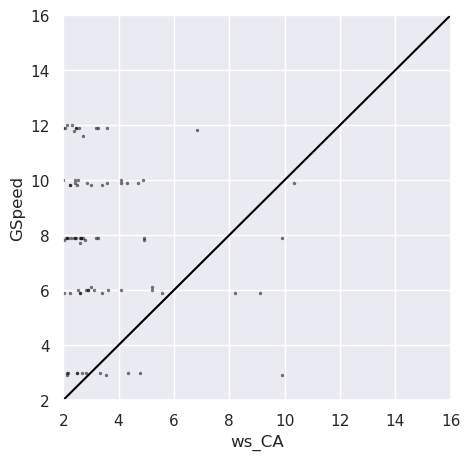

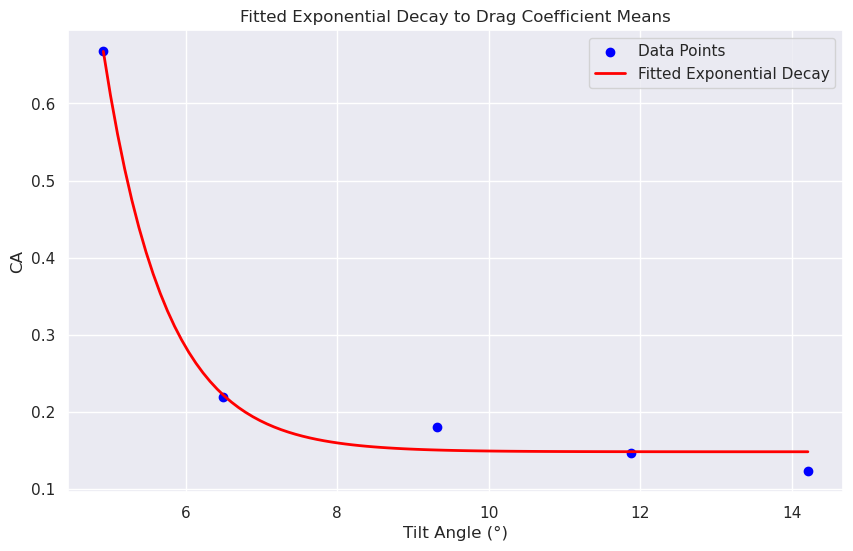

In [18]:
# Select direction
#fr_df = fr_df.loc[(fr_df['orientation'] == 'forward') | (fr_df['orientation'] == 'backward')]
#fr_df = fr_df.loc[(fr_df['orientation'] == 'leftward') | (fr_df['orientation'] == 'rightward')]

def calculate_CA(df, mass, dimension, air_density):
    # Parameters
    g = 9.81  # Gravity in m/s^2
    r = dimension / 100  # Convert dimension from cm to meters
    A_0 = np.pi * np.power(r, 2)  # Reference area

    # Extract necessary columns
    tilt_angle = df['tilt_deg']
    groundspeed = df['GSpeed']

    # Calculate the k_coefficient
    k_coefficient = (air_density * A_0) / (2 * mass * g)

    # Calculate the drag coefficient Ca
    Ca = np.tan(np.radians(tilt_angle)) / (k_coefficient * np.power(groundspeed, 2))
    return Ca

# Example parameters, from Juelich I believe they refer to Mavic3 (Flik)
mass = 1.2  # mass of the drone in kg
dimension = 30  # rotor radius or characteristic dimension in cm
air_density = 1.225  # air density in kg/m^3 (standard at sea level)

# Calculate drag coefficient and add to DataFrame
# According to Eq. 33 of Bramati you compute and then take the mean CA
fr_df['CA'] = np.nan
for orientation in orientations_dict:
    fr_df.loc[fr_df['orientation'] == orientation,'CA'] = calculate_CA(fr_df.loc[fr_df['orientation'] == orientation], mass, dimension, air_density)

# Drop rows where Ca > 5
#fr_df = fr_df[fr_df['CA'] <= 5]

fig,axes=plt.subplots(1,2,figsize=(16,5))
sns.scatterplot(
    data=fr_df,
    x='tilt_deg',
    y='CA',
    hue='orientation',
    edgecolor=None,
    s=5,
    ax=axes[0],
    )

sns.scatterplot(
    data=fr_df,
    x='tilt_deg',
    y='CA',
    hue='GSpeed',
    edgecolor=None,
    s=5,
    ax=axes[1],
    )


import scipy.stats as stats

# Define the speed bins with edges at 1 m/s below and above each target speed
bins = GSpeed_values-0.5*np.ones_like(GSpeed_values)
bins = np.concatenate((bins,[GSpeed_values[-1]+0.5]))
labels = [ f"{GSpeed_value} m/s" for GSpeed_value in GSpeed_values]  # Corresponding labels

# Create a new column in the filtered data for the speed classes
fr_df['GSpeed_class'] = pd.cut(fr_df['GSpeed'], bins=bins, labels=labels)

# Group the data by the speed classes and calculate the mean for each group
grouped_means = fr_df[['CA','GSpeed','GSpeed_class','tilt_deg']].groupby('GSpeed_class').mean()

#%% plots for the means

import matplotlib.pyplot as plt

# Plot the mean horizontal speed vs. mean tilt angle
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grouped_means,
    x='tilt_deg',
    y='GSpeed',
    edgecolor=None,
)
# Plot the mean drag coefficient Ca vs. mean tilt angle
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=grouped_means,
    x='tilt_deg',
    y='CA',
    edgecolor=None,
)


#%% Calculate the exponential decay fit
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the exponential decay function
def exponential_decay(tilt_deg, c0, c1, c2):
    return c0 + c1 * np.exp(-tilt_deg / c2)

# Extract the tilt angle (G) and drag coefficient means (Ca) from the grouped_means
tilt_deg = grouped_means['tilt_deg'].dropna().values
CA_means = grouped_means['CA'].dropna().values

# Fit the exponential decay function to the data
popt, pcov = curve_fit(exponential_decay, tilt_deg, CA_means, maxfev=10000)

# Extract the fitted parameters
c0, c1, c2 = popt
print(f"Fitted parameters: c0 = {c0}, c1 = {c1}, c2 = {c2}")

def calculate_ws_CA(df,c0,c1,c2, mass, dimension, air_density):
    # Parameters
    g = 9.81  # Gravity in m/s^2
    r = dimension / 100  # Convert dimension from cm to meters
    A_0 = np.pi * np.power(r, 2)  # Reference area


    # Calculate the k_coefficient
    k_coefficient = (air_density * A_0) / (2 * mass * g)

    # Calculate the drag coefficient Ca
    ws_CA = np.sqrt(np.tan(df['tilt_rad'] / (k_coefficient * exponential_decay(df['tilt_deg'],c0,c1,c2))))
    
    return ws_CA

fr_df['ws_CA'] = calculate_ws_CA(fr_df,c0,c1,c2, mass, dimension, air_density)

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=fr_df,
    x='ws_CA',
    y='GSpeed',
    color='black',
    edgecolor=None,
    s=5,
    alpha=0.5,    
)
plt.plot(np.arange(0,17,1),color='black')
plt.xlim((2,16))
plt.ylim((2,16))
print(f"c2 : {c2},c1 : {c1},c0 : {c0}")
plt.show()


# Generate values for the fitted curve
tilt_deg_fit = np.linspace(min(tilt_deg), max(tilt_deg), 100)
CA_fit = exponential_decay(tilt_deg_fit, c0, c1, c2)

# Plot the original data and the fitted curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(tilt_deg, CA_means, color='blue', label='Data Points')
ax.plot(tilt_deg_fit, CA_fit, color='red', label='Fitted Exponential Decay', linewidth=2)
ax.set_title('Fitted Exponential Decay to Drag Coefficient Means')
ax.set_xlabel('Tilt Angle (°)')
ax.set_ylabel('CA')
ax.legend()

plt.show()
